In [1]:
import numpy as np
import scanpy as sc
import json
from app.task import load_partitioned_anndata, get_gene_index_name_dict, get_initial_gene_list
import sys
import os
import random

SEED = 55
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

def compute_aligned_stats(adata, global_gene_list):
    """
    Computes and returns local statistics (mean and mean of squares) for each gene,
    aligned to a global gene list. This function directly mimics the client's fit method.
    """
    # N_i: number of samples (cells) for this client
    num_examples = adata.n_obs
    
    # Initialize arrays for local means and local means of squares
    aligned_mean_scores = np.zeros(len(global_gene_list), dtype=np.float32)
    aligned_mean_of_squares_scores = np.zeros(len(global_gene_list), dtype=np.float32)

    # Get the expression matrix, handling potential sparse format
    X_matrix = adata.X.A if hasattr(adata.X, 'A') else adata.X
    gene_to_index = {gene: i for i, gene in enumerate(adata.var_names)}

    # Iterate through the global gene list to compute and align statistics
    for i, global_gene in enumerate(global_gene_list):
        if global_gene in gene_to_index:
            local_index = gene_to_index[global_gene]
            gene_expression = X_matrix[:, local_index]
            
            # Calculate local mean and local mean of squares for the gene
            local_mean_gene = np.mean(gene_expression)
            local_mean_of_squares_gene = np.mean(gene_expression ** 2)
            
            aligned_mean_scores[i] = local_mean_gene
            aligned_mean_of_squares_scores[i] = local_mean_of_squares_gene

    return aligned_mean_scores, aligned_mean_of_squares_scores, num_examples

def aggregate_stats(locals_stats):
    """
    Aggregate local statistics into global variance using weighted average.
    locals_stats: List of tuples (gene_means, gene_mean_squares, n_cells)
    """
    total_cells = sum(n for _, _, n in locals_stats)
    if total_cells == 0:
        raise ValueError("No cells found in local datasets")
    
    num_genes = len(locals_stats[0][0])
    global_mean = np.zeros(num_genes)
    global_mean_squares = np.zeros(num_genes)
    
    for gene_means, gene_mean_squares, n_cells in locals_stats:
        weight = n_cells / total_cells
        global_mean += gene_means * weight
        global_mean_squares += gene_mean_squares * weight
    
    global_variance = global_mean_squares - (global_mean ** 2)
    return global_variance

def select_top_hvg(global_variance, top_n=2000):
    """
    Select top N genes by variance and return sorted indices.
    """
    top_indices = np.argsort(global_variance)[-top_n:][::-1]
    return sorted([int(i) for i in top_indices])

def main_compare_hvg(n_clients=3):
    global fed_hvg_indices, hvg_names
    local_stats = []

    # Get the global gene list, mimicking the server's setup
    global_gene_list = get_initial_gene_list(path="../data/pancreas_train.h5ad")
    
    for n in range(n_clients):
        adata = load_partitioned_anndata(partition_id=n, num_partitions=n_clients, adata_path=os.path.join("..","data", "pancreas_train.h5ad"))

        # Use the new function that mimics the client's fit method
        means, mean_squares, n_cells = compute_aligned_stats(adata, global_gene_list)
        local_stats.append((means, mean_squares, n_cells))
        
    # Aggregate local statistics (simulate federated aggregation without privacy)
    aggregated_variance = aggregate_stats(local_stats)
    
    # Select top 2000 HVGs
    top_hvg_indices = select_top_hvg(aggregated_variance, top_n=2000)
    
    # Map indices to gene names
    idx_to_name = get_gene_index_name_dict("../data/pancreas_train.h5ad")
    hvg_names = [idx_to_name[i] for i in top_hvg_indices]
    
    # Save outputs
    with open("./independent_hvg_indices.json", "w") as f:
        json.dump(top_hvg_indices, f)
    with open("./independent_hvg_list.json", "w") as f:
        json.dump(hvg_names, f)
    
    print("Independent client HVG analysis completed.")
    print(f"Top 10 HVG indices: {top_hvg_indices[:10]}")
    print(f"Top 10 HVG names: {hvg_names[:10]}")

    with open("./hvg_indices.json") as f:
        fed_hvg_indices = set(json.load(f))

    overlap = fed_hvg_indices.intersection(top_hvg_indices)
    jaccard = len(overlap) / len(fed_hvg_indices.union(top_hvg_indices))

    print(f"Number of overlapping HVGs: {len(overlap)}")
    print(f"Jaccard similarity: {jaccard:.4f}")

if __name__ == "__main__":
    main_compare_hvg(n_clients=3)

Global gene list: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AA06', 'AAAS', 'AACS', 'AACSP1']... Total genes: 19093
Independent client HVG analysis completed.
Top 10 HVG indices: [22, 66, 84, 95, 102, 118, 129, 134, 136, 154]
Top 10 HVG names: ['AARS', 'ABCC8', 'ABHD12', 'ABHD2', 'ABI2', 'ACAA2', 'ACADVL', 'ACAT1', 'ACBD3', 'ACLY']
Number of overlapping HVGs: 2000
Jaccard similarity: 1.0000


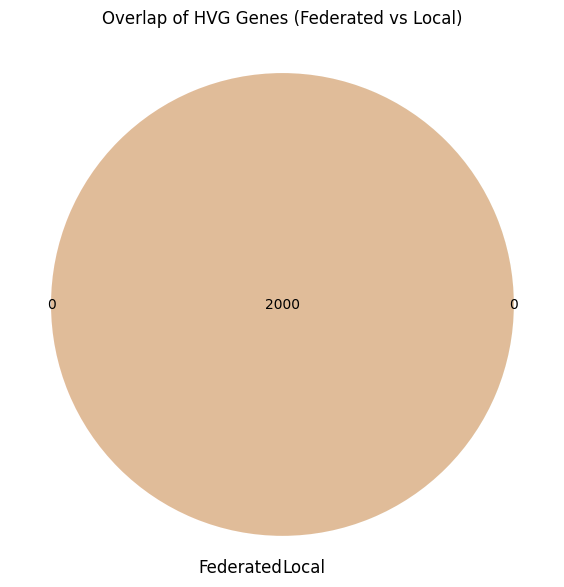

In [2]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Convert to sets of gene names for better comparison
idx_to_gene = get_gene_index_name_dict("../data/pancreas_train.h5ad")

federated_genes = {idx_to_gene[i] for i in fed_hvg_indices}
hvg_idx_names = set(hvg_names)
plt.figure(figsize=(6, 6))
venn2([federated_genes, hvg_idx_names], set_labels=('Federated', 'Local'))
plt.title("Overlap of HVG Genes (Federated vs Local)")
plt.tight_layout()
plt.show()
